<a href="https://colab.research.google.com/github/nahid1602/Deep_Learning_Practice/blob/main/CNN_p1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [3]:
(X_train, y_train),(X_test, y_test) =datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [4]:
X_train.shape, X_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

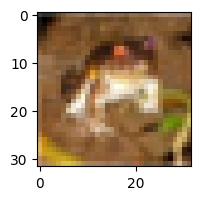

In [5]:
plt.figure(figsize=(15,2))
plt.imshow(X_train[0])

In [6]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [7]:
y_index = y_train.ravel() # Matrix is converted to 1D Array.

In [8]:
y_index

array([6, 9, 9, ..., 9, 1, 1], dtype=uint8)

In [9]:
classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

In [102]:
def plot_sample(X,y,index):
  plt.figure(figsize=(1,2))
  plt.imshow(X[index])
  plt.xlabel(classes[y[index]])

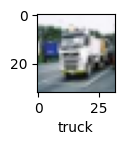

In [125]:
plot_sample(X_train,y_index,1000)

In [12]:
X_train_norm = X_train/255.0
X_test_norm = X_test/255.0

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D

In [14]:
model = Sequential([
    Flatten(input_shape=(32, 32, 3)),  # e.g., (28, 28, 1) for MNIST
    Dense(3000, activation='relu'),
    Dense(1000, activation='relu'),
    Dense(10, activation='softmax')  # 10 classes for classification
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # use categorical_crossentropy if one-hot labels
    metrics=['accuracy']
)

In [16]:
model.fit(X_train_norm, y_train, epochs=30, validation_data=(X_test_norm, y_test))

Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.2775 - loss: 2.2367 - val_accuracy: 0.3767 - val_loss: 1.7065
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.3883 - loss: 1.6889 - val_accuracy: 0.4358 - val_loss: 1.5944
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4245 - loss: 1.6004 - val_accuracy: 0.4446 - val_loss: 1.5488
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.4447 - loss: 1.5418 - val_accuracy: 0.4575 - val_loss: 1.5099
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.4666 - loss: 1.4830 - val_accuracy: 0.4678 - val_loss: 1.4901
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.4770 - loss: 1.4578 - val_accuracy: 0.4815 - val_loss: 1.4651
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.4930 - loss: 1.4179 - val_accuracy: 0.4703 - val_loss: 1.4940
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.4999 - loss: 1.399

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

In [18]:
y_pred_prob = model.predict(X_test_norm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [19]:
y_pred_prob.shape

(10000, 10)

In [20]:
y_pred = y_pred_prob.argmax(axis=1)

              precision    recall  f1-score   support

           0       0.52      0.58      0.55      1000
           1       0.67      0.51      0.58      1000
           2       0.36      0.42      0.39      1000
           3       0.33      0.36      0.34      1000
           4       0.47      0.32      0.38      1000
           5       0.45      0.30      0.36      1000
           6       0.46      0.63      0.53      1000
           7       0.57      0.57      0.57      1000
           8       0.56      0.70      0.62      1000
           9       0.60      0.52      0.56      1000

    accuracy                           0.49     10000
   macro avg       0.50      0.49      0.49     10000
weighted avg       0.50      0.49      0.49     10000



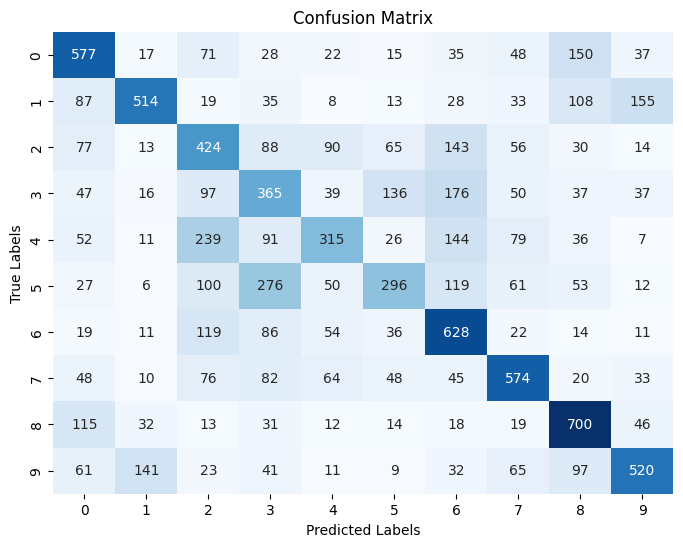

In [21]:
import seaborn as sns
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [35]:


cnn = Sequential([
    #First convolutional layer
    Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    #Second convolutional layer
    Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    #Neural Network layer
    Flatten(),  # e.g., (28, 28, 1) for MNIST
    Dense(3000, activation='relu'),
    Dense(1000, activation='relu'),
    Dense(10, activation='softmax')
])

In [36]:
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # use categorical_crossentropy if one-hot labels
    metrics=['accuracy']
)

In [37]:
cnn.fit(X_train_norm, y_train, epochs=30, validation_data=(X_test_norm, y_test))

Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.4123 - loss: 1.6011 - val_accuracy: 0.6354 - val_loss: 1.0523
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.6636 - loss: 0.9562 - val_accuracy: 0.6745 - val_loss: 0.9291
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7533 - loss: 0.7082 - val_accuracy: 0.7044 - val_loss: 0.8672
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8288 - loss: 0.4952 - val_accuracy: 0.6945 - val_loss: 0.9588
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8936 - loss: 0.3063 - val_accuracy: 0.7054 - val_loss: 1.0780
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9354 - loss: 0.1854 - val_accuracy: 0.7041 - val_loss: 1.2746
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9574 - loss: 0.1269 - val_accuracy: 0.6979 - val_loss: 1.3933
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9640 - loss: 0.10

In [38]:
y_pred_prob_c = cnn.predict(X_test_norm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [39]:
y_pred_prob_c.shape

(10000, 10)

In [40]:
y_pred_c = y_pred_prob_c.argmax(axis = 1)

              precision    recall  f1-score   support

           0       0.69      0.77      0.73      1000
           1       0.80      0.80      0.80      1000
           2       0.62      0.60      0.61      1000
           3       0.50      0.47      0.49      1000
           4       0.68      0.60      0.63      1000
           5       0.56      0.60      0.58      1000
           6       0.79      0.70      0.74      1000
           7       0.76      0.72      0.74      1000
           8       0.74      0.83      0.79      1000
           9       0.74      0.80      0.77      1000

    accuracy                           0.69     10000
   macro avg       0.69      0.69      0.69     10000
weighted avg       0.69      0.69      0.69     10000



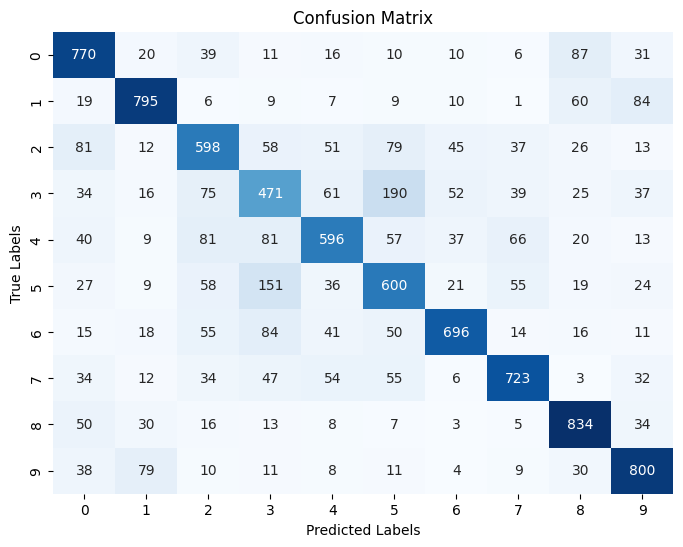

In [41]:
print(classification_report(y_test, y_pred_c))
cm = confusion_matrix(y_test, y_pred_c)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

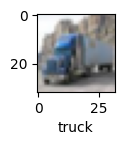

In [124]:
plot_sample(X_test,y_pred_c,504)